In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re

### Load Solutions

In [4]:
def load_solutions(filepath):
    # Dictionary to store final solutions keyed by date
    solutions = {}

    # Read entire file content as a single string
    with open(filepath, encoding='utf-8') as f:
        content = f.read()

    # Split file into blocks using separator line
    blocks = content.strip().split('----------------------------------------')

    for block in blocks:
        # Extract date in format YYYY-MM-DD using regex
        date_m = re.search(r'Date:\s*(\d{4}-\d{2}-\d{2})', block)

        # Skip block if no valid date found
        if not date_m:
            continue

        # Convert date format from YYYY-MM-DD → YYYY_MM_DD for dictionary key
        date = date_m.group(1).replace('-', '_')

        # Get everything after "Solution:" section
        sol_section = block.split('Solution:')[-1]

        # Extract all uppercase letters (assumes solution is encoded as letters)
        letters = re.findall(r'[A-Z]', sol_section)

        # Join letters into final solution string and store by date
        solutions[date] = ''.join(letters)

    return solutions

# Load solutions from file into dictionary
solutions = load_solutions('./crossword_output/monday_solutions.txt')

### Load Ranking Method Folders

In [ ]:
def parse_log(filepath, solution):
    df = pd.read_csv(filepath)

    # Count how many times each action appears (backtrack, print_grid, etc.)
    actions = df['action'].value_counts().to_dict()

    # If "failed_solve" never appears, we assume the model reported success
    reported_solved = 'failed_solve' not in df['action'].values

    # Count number of backtracking steps
    backtracks = actions.get('backtrack', 0)

    # Extract all grid snapshots (printed states of the puzzle)
    grids = df[df['action'] == 'print_grid']['message']

    # Take the last grid output and extract uppercase letters from it
    grid_letters = ''.join(re.findall(r'[A-Z]', grids.iloc[-1])) if len(grids) > 0 else ''

    # Compare extracted solution with ground truth solution (if available)
    if solution:
        # Compare only up to the shorter length
        min_len = min(len(grid_letters), len(solution))

        # Count position-wise matches
        matches = sum(g == s for g, s in zip(grid_letters[:min_len], solution[:min_len]))

        # Compute accuracy as percentage of correct letters
        letter_acc = (matches / len(solution) * 100) if len(solution) > 0 else 0.0

        # Full match check (exact solution match)
        truly_solved = grid_letters == solution
    else:
        # If no solution exists, default values
        letter_acc = 0.0
        truly_solved = False

    # Return computed metrics for this log file
    return {
        'backtracks': backtracks,
        'reported_solved': reported_solved,
        'truly_solved': truly_solved,

        # True if model claimed success but did not actually solve correctly
        'false_positive': reported_solved and not truly_solved,

        # Rounded accuracy of extracted letters vs true solution
        'letter_accuracy': round(letter_acc, 1)
    }


def load_folder(folder, solutions):
    # Store results for all files
    rows = []

    # Iterate through all files in folder (sorted for consistent ordering)
    for fname in sorted(os.listdir(folder)):

        # Only process CSV log files
        if not fname.endswith('.csv'):
            continue

        # Extract date from filename (format: YYYY_MM_DD)
        date_m = re.search(r'(\d{4}_\d{2}_\d{2})', fname)
        date = date_m.group(1) if date_m else fname.replace('.csv', '')

        # Get corresponding ground truth solution for that date
        sol = solutions.get(date, '')

        # Parse log file and compute metrics
        result = parse_log(os.path.join(folder, fname), sol)

        # Attach date to result
        result['date'] = date

        # Add row to dataset
        rows.append(result)

    # Convert list of dictionaries into DataFrame
    return pd.DataFrame(rows)

In [ ]:
# Defining folder paths
folders = {
    'None':'./ranking_methods/crosswords_none',
    'Vagueness and Complexity':'./ranking_methods/Vagueness-and-Complexity/',
    'Vagueness and Complexity\n with Known Letters':'./ranking_methods/Vagueness-and-Complexity-Plus-Known-Letters/'
}

dfs = []
for method_name, folder_path in folders.items():
    df = load_folder(folder_path, solutions)
    df['method'] = method_name
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
all_df.head()

,backtracks,reported_solved,truly_solved,false_positive,letter_accuracy,date,method
0,46,False,False,False,4.3,2025_01_06,None
1,45,False,False,False,0.0,2025_01_13,None
2,43,False,False,False,0.0,2025_01_20,None
3,48,False,False,False,4.3,2025_01_27,None
4,45,False,False,False,0.0,2025_02_03,None


### Graph 1 — Average Backtracks per Ranking Method

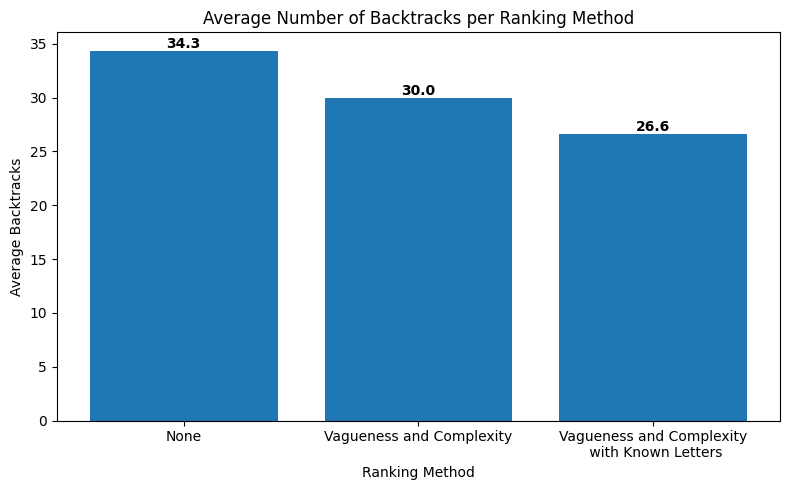

In [5]:
# Compute average number of backtracks per method
avg_bt = all_df.groupby('method')['backtracks'].mean().reset_index(name='avg_backtracks')
plt.figure(figsize=(8, 5))

# Plot bar chart: method vs average backtracks
plt.bar(avg_bt['method'], avg_bt['avg_backtracks'])

plt.xlabel('Ranking Method')
plt.ylabel('Average Backtracks')
plt.title('Average Number of Backtracks per Ranking Method')

# Add value labels on top of each bar
for i, v in enumerate(avg_bt['avg_backtracks']):
    plt.text(
        i, 
        v + 0.3,  # small vertical offset so text sits above bar
        f'{v:.1f}', 
        ha='center', 
        fontweight='bold'
    )

# Adjust layout to prevent clipping
plt.tight_layout()

plt.savefig('./crossword_output/1_avg_backtracks.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 2 — Solve Rate per Ranking Method (including false positives)

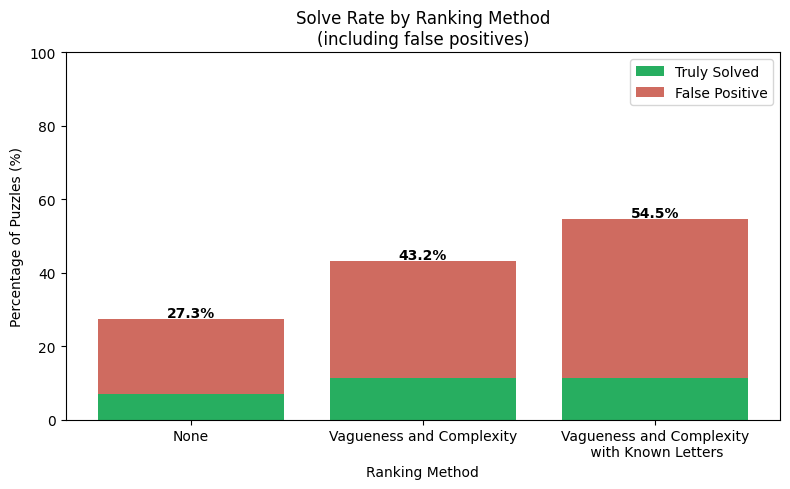

In [6]:
# Group data by method and compute key metrics
solve_rate = all_df.groupby('method').agg(
    total=('truly_solved', 'count'),        # total number of puzzles per method
    truly_solved=('truly_solved', 'sum'),   # number of correct solutions
    false_positives=('false_positive', 'sum')  # incorrect "claimed solved" cases
).reset_index()

# Convert counts into percentages
solve_rate['true_pct'] = solve_rate['truly_solved'] / solve_rate['total'] * 100
solve_rate['fp_pct']   = solve_rate['false_positives'] / solve_rate['total'] * 100

# Method names for x-axis
methods = solve_rate['method']

plt.figure(figsize=(8, 5))

# Stacked bar chart:
# Bottom = truly solved
plt.bar(methods, solve_rate['true_pct'], color='#27ae60', label='Truly Solved')

# Top = false positives stacked on top of true solves
plt.bar(
    methods,
    solve_rate['fp_pct'],
    color='#c0392b',
    alpha=0.75,
    bottom=solve_rate['true_pct'],
    label='False Positive'
)

# Add total percentage labels on top of each stacked bar
for i, row in solve_rate.iterrows():
    total = row['true_pct'] + row['fp_pct']
    plt.text(
        i,
        total + 0.5,   # small offset above bar
        f"{total:.1f}%",
        ha='center',
        fontweight='bold'
    )

plt.xlabel('Ranking Method')
plt.ylabel('Percentage of Puzzles (%)')
plt.title('Solve Rate by Ranking Method\n(including false positives)')

plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig('./crossword_output/2_solve_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 3 — Letter Accuracy per Ranking Method

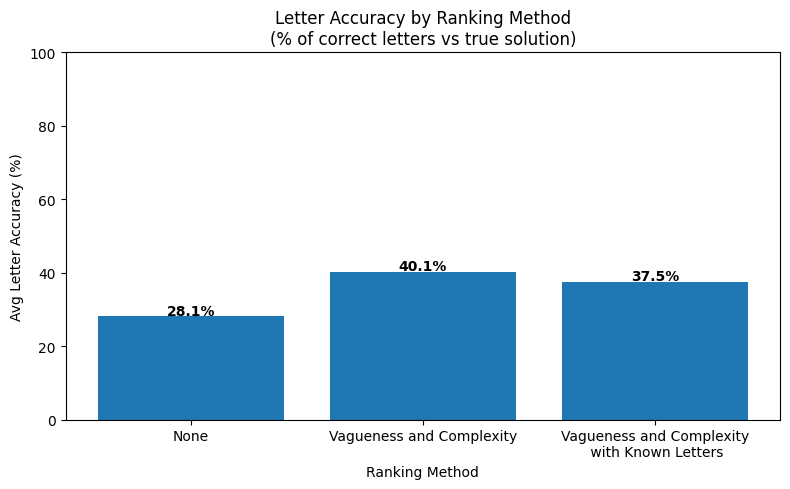

In [26]:
# Compute average letter-level accuracy per method
# (how closely predicted letters match the true solution on average)
letter_acc = all_df.groupby('method')['letter_accuracy'].mean().reset_index(name='avg_letter_accuracy')
plt.figure(figsize=(8, 5))

# Plot bar chart: method vs average letter accuracy
plt.bar(letter_acc['method'], letter_acc['avg_letter_accuracy'])

plt.xlabel('Ranking Method')
plt.ylabel('Avg Letter Accuracy (%)')
plt.title('Letter Accuracy by Ranking Method\n(% of correct letters vs true solution)')
plt.ylim(0, 100)

# Add value labels above each bar
for i, v in enumerate(letter_acc['avg_letter_accuracy']):
    plt.text(
        i,
        v + 0.5,   # small offset so text sits above bar
        f'{v:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('./crossword_output/3_letter_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# Letter Accuracy for Each Puzzle

In [ ]:
# Get data
folders = {
    'None':'../None',
    'Vagueness and Complexity':'../Vagueness-and-Complexity/',
    'Vagueness and Complexity\n with Known Letters':'../Vagueness-and-Complexity-Plus-Known-Letters/'
}

dfs = []
for method_name, folder_path in folders.items():
    df = load_folder(folder_path, solutions)
    df['method'] = method_name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
# print(data[["date", "method", "letter_accuracy"]])

bins = [0, 50, 60, 70, 80, 90, 99, 100]
labels = ['<50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-99%', '100%']

data["accuracy_range"] = pd.cut(data["letter_accuracy"], bins=bins, labels=labels, include_lowest=True)

# Count number of puzzles per method per bucket
bucket_counts = (data.groupby(["method", "accuracy_range"]).size().unstack(fill_value=0))
# print(bucket_counts)

accuracy_range                                 <50%  50-60%  60-70%  70-80%  \
method                                                                        
None                                             36       1       2       4   
Vagueness and Complexity                         33       3       2       3   
Vagueness and Complexity\n with Known Letters    31       2       1       3   

accuracy_range                                 80-90%  90-99%  100%  
method                                                               
None                                                3       1     3  
Vagueness and Complexity                            2       2     5  
Vagueness and Complexity\n with Known Letters       3       2     8  


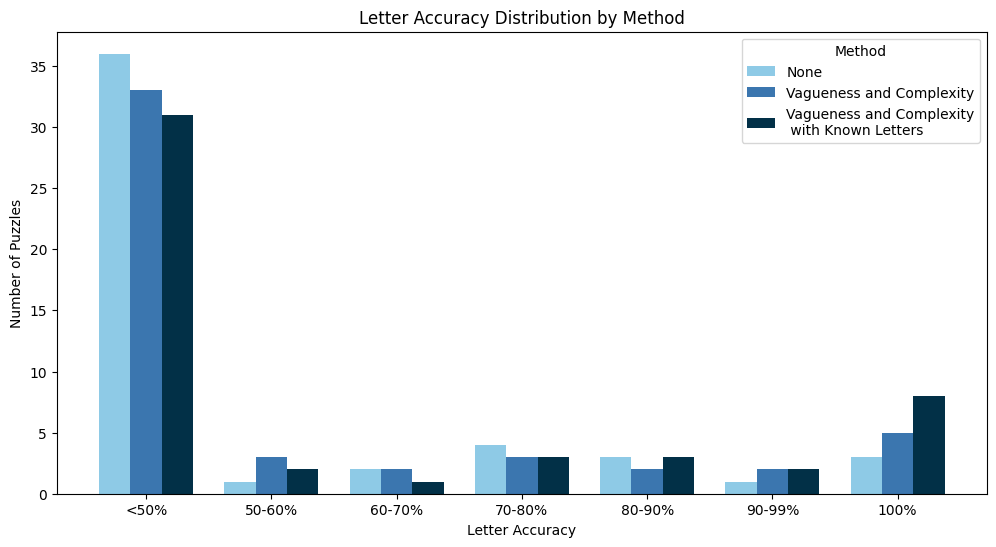

In [27]:
# Plot grouped bars
x = np.arange(len(labels))
width = 0.25
methods = bucket_counts.index
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#8ecae6", "#3B76af", "#023047"]

for i, method in enumerate(methods):
    ax.bar(x + i * width, bucket_counts.loc[method], width, label=method, color=colors[i])

# Labels and formatting
ax.set_xlabel("Letter Accuracy")
ax.set_ylabel("Number of Puzzles")
ax.set_title("Letter Accuracy Distribution by Method")

ax.set_xticks(x + width)
ax.set_xticklabels(labels)

ax.legend(title="Method")

plt.show()